In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [127]:
data=pd.read_csv('Retail_sales.csv')
data

,transaction_id,transaction_date,customer_id,gender,Age,product_name,category,quantity,unit_price,sales,payment_method,sales_channel
0,T0000001,4/24/2024,C000820,Male,34,Dumbbells,Sports,2,313.53,627.06,Debit Card,Online
1,T0000002,7/12/2025,C002849,Male,26,Running Shoes,Sports,1,366.16,366.16,Credit Card,Online
2,T0000003,6/1/2025,C019727,Male,50,Sneakers,Clothing,1,27.99,27.99,Gift Card,In-Store
3,T0000004,8/26/2025,C009116,Male,37,Sunscreen,Beauty,2,102.01,204.02,Cash,In-Store
4,T0000005,12/10/2024,C003350,Male,30,Sneakers,Clothing,1,259.55,259.55,Cash,In-Store
...,...,...,...,...,...,...,...,...,...,...,...,...
994,T0000995,9/27/2024,C016941,Female,41,Novel,Books,1,208.14,208.14,Cash,Mobile App
995,T0000996,6/3/2024,C018209,Male,62,Board Game,Toys,1,216.63,216.63,Debit Card,Online
996,T0000997,7/6/2024,C001176,Female,52,Sneakers,Clothing,1,27.99,27.99,PayPal,In-Store
997,T0000998,5/21/2025,C001337,Female,23,Textbook,Books,2,318.53,637.06,PayPal,In-Store


In [128]:
data.shape

(999, 12)

In [129]:
data.dtypes

transaction_id       object
transaction_date     object
customer_id          object
gender               object
Age                   int64
product_name         object
category             object
quantity              int64
unit_price          float64
sales               float64
payment_method       object
sales_channel        object
dtype: object

In [130]:
data.isnull().sum()

transaction_id      0
transaction_date    0
customer_id         0
gender              0
Age                 0
product_name        0
category            0
quantity            0
unit_price          0
sales               0
payment_method      0
sales_channel       0
dtype: int64

In [161]:
cols = ['Age', 'quantity', 'unit_price', 'sales']
stats = {
    'Mean': data[cols].mean(),
    'Median': data[cols].median(),
    'Mode': data[cols].mode().iloc[0],
    'Std Dev': data[cols].std()
}

summary_table = pd.DataFrame(stats).T

summary_table

,Age,quantity,unit_price,sales
Mean,41.386386,1.685686,235.420350,393.378619
Median,42.000000,1.000000,222.880000,307.870000
Mode,43.000000,1.000000,444.170000,444.170000
Std Dev,13.687130,1.037042,145.364677,364.495475


In [132]:
data['transaction_date'] = pd.to_datetime(data['transaction_date'])
data.set_index('transaction_date', inplace=True)

C:\Users\ALI PC\AppData\Local\Temp\ipykernel_16464\3153545245.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales=data['sales'].resample('M').sum()


Text(0.5, 1.0, 'Monthly Sales Trend')

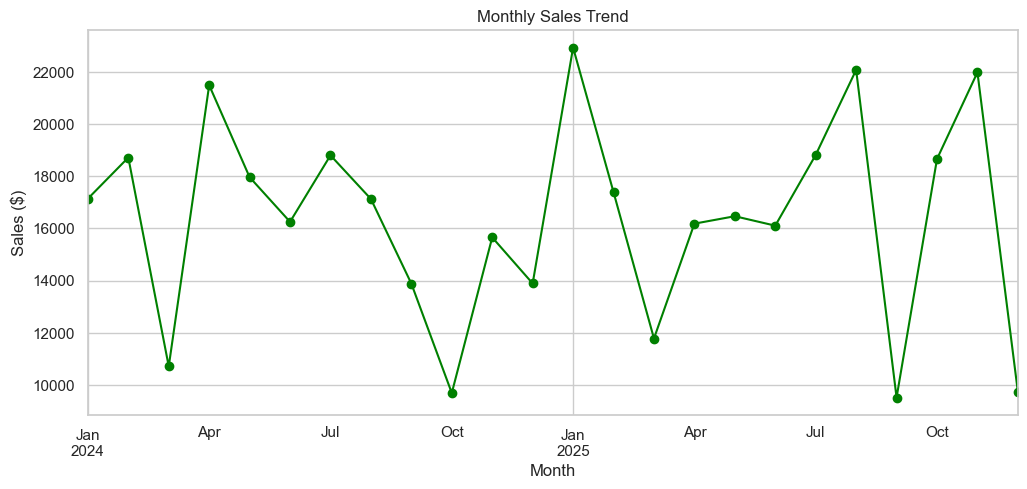

In [215]:
monthly_sales=data['sales'].resample('M').sum()
plt.figure(figsize=(12, 5))
monthly_sales.plot(color='green',marker='o')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.title('Monthly Sales Trend')


### Monthly Sales Trend Analysis
* **High Volatility & Cyclical Spikes:** Sales exhibit sharp month-over-month volatility. A highly pronounced peak performance occurs in **January 2025** (surpassing \$22,000), indicating strong post-holiday or early-year consumer demand.
* **Severe Autumn Dips:** Steep declines consistently occur in the autumn months, specifically in **October 2024** and **September 2025**, with sales crashing below \$10,000. 
* **Actionable Insight:** The recurring drop in September and October indicates a consistent pre-holiday purchasing lull. To stabilize this off-season revenue, marketing efforts, clearance events, and promotional push campaigns should be strategically scheduled during these specific low periods.

C:\Users\ALI PC\AppData\Local\Temp\ipykernel_16464\1045284088.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sales=data['sales'].resample('Q').sum()


Text(0.5, 1.0, 'Quarterly Sales Trend')

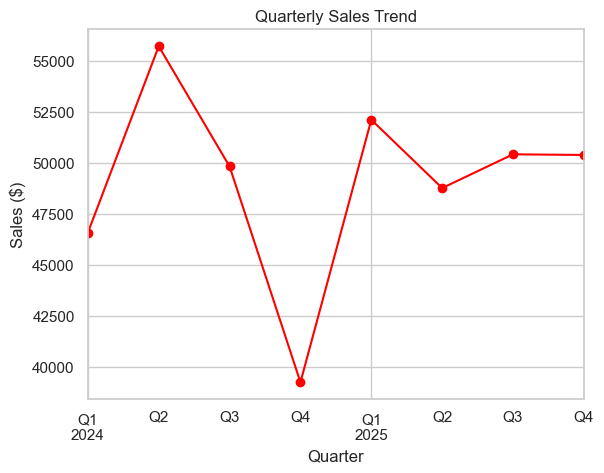

In [216]:
quarterly_sales=data['sales'].resample('Q').sum()
quarterly_sales.plot(color='red',marker='o')
plt.xlabel('Quarter')
plt.ylabel('Sales ($)')
plt.title('Quarterly Sales Trend')

### Quarterly Sales Trend Analysis
* **The Q4 Anomalous Dip:** Although Q2 of 2024 shows our highest performance (over \$55,000 in sales), **Q4 2024 represents a massive performance trough**, dropping below \$40,000. This directly matches the severe monthly dip observed in October.
* **Stable recovery:** Post-Q4 2024, sales recovered sharply in Q1 2025 (surpassing \$52,000) and stabilized around a steady \$50,000 baseline throughout Q3 and Q4 of 2025.
* **Key Insight:** Our business does not follow the traditional retail pattern where Q4 is the strongest quarter. Identifying why Q4 underperforms is crucial for long-term growth.

Text(0.5, 1.0, 'Age Distribution')

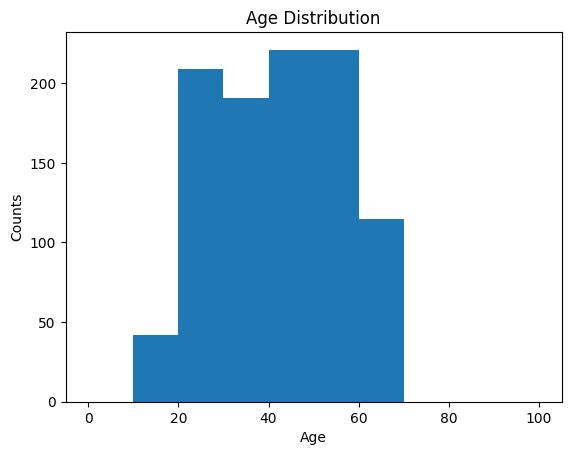

In [135]:
plt.hist(data['Age'],bins=[0,10,20,30,40,50,60,70,80,90,100])
plt.xlabel('Age')
plt.ylabel('Counts')
plt.title('Age Distribution')

### Customer Age Demographics
* **Target Audience Concentration:** The vast majority of our customer base is concentrated between the ages of **20 and 60**. 
* **Peak Segments:** The two largest age cohorts are the **20–30 group** and the **40–60 group**, both reaching well over 200 customer counts. 
* **Untapped Demographics:** There is nearly zero customer engagement under the age of 10 and over the age of 70, with a major drop-off occurring after age 60.
* **Key Insight:** Product offerings and platform design should be optimized to appeal to these two main pillars: young adult shoppers and middle-aged consumers.

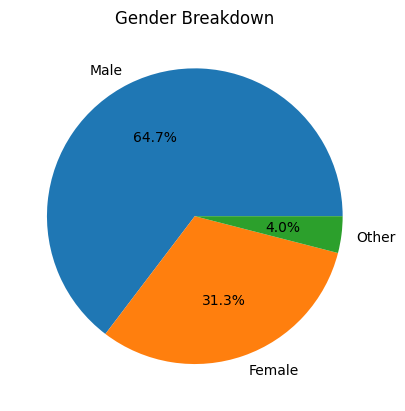

In [136]:
data['gender'].value_counts().plot(kind='pie',autopct='%0.1f%%',title='Gender Breakdown',ylabel='');

### Gender Breakdown Analysis
* **Male Dominance:** Male customers represent the supermajority of our consumer base, accounting for **64.7%** of all transactions.
* **Female & Other representation:** Female shoppers comprise **31.3%** of our user base, while individuals identifying as "Other" make up **4.0%**.
* **Key Insight:** Since nearly two-thirds of our market is male, marketing campaigns have likely been skewed toward products favoring men. There is a high-potential opportunity to target underrepresented female demographics with dedicated campaigns to expand market share.

<Axes: title={'center': 'top 10 best-selling products'}, xlabel='product_name'>

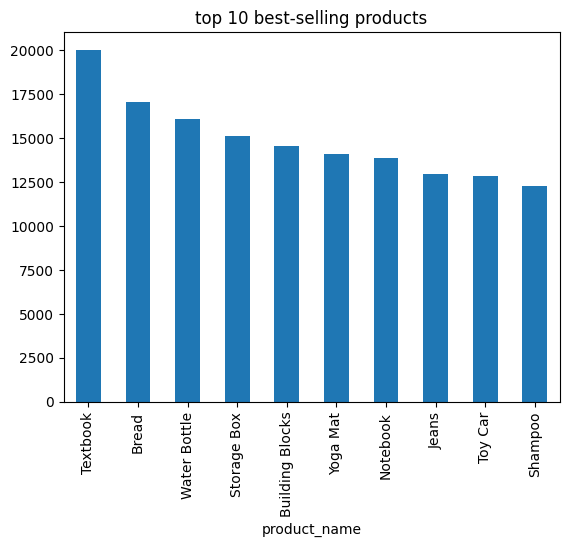

In [157]:
data.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar',title='top 10 best-selling products')

### Best-Selling Products Analysis
* **Top Revenue Drivers:** **Textbooks** are our absolute best-selling individual product, securing over 20,000 in units/sales. **Bread** and **Water Bottles** round out the top three.
* **Diverse Top 10:** The top products span incredibly diverse categories, including educational items (Textbooks, Notebooks), food/essentials (Bread, Water Bottles, Shampoo), and lifestyle/play items (Yoga Mats, Toy Cars, Jeans).
* **Key Insight:** Educational resources are a powerful driver of our sales volume, suggesting a strong student or parent demographic within our consumer base.

<Axes: title={'center': 'revenue by product category'}, xlabel='category'>

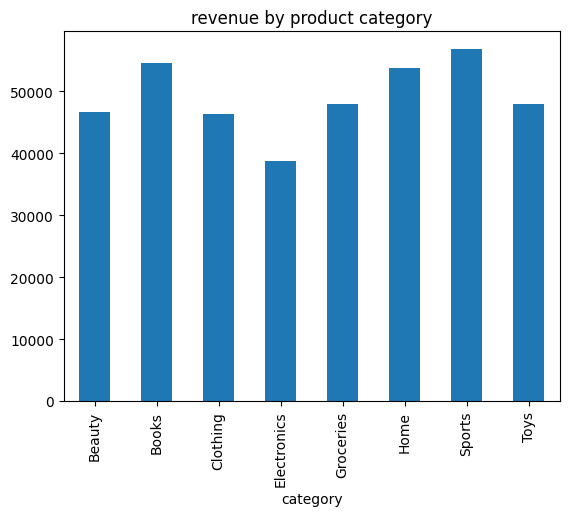

In [160]:
data.groupby('category')['sales'].sum().plot(kind='bar',title='revenue by product category')

### Category Revenue Contribution
* **Leading Categories:** **Sports** is our highest-grossing category (generating well over \$55,000), closely followed by **Books** and **Home**.
* **Underperforming Category:** **Electronics** is our lowest revenue contributor, bringing in under \$40,000.
* **Equilibrium:** Most remaining categories such as Beauty, Clothing, Groceries, and Toys display highly balanced and stable performance, each hovering between \$45,000 and \$50,000 in overall revenue.

<Axes: >

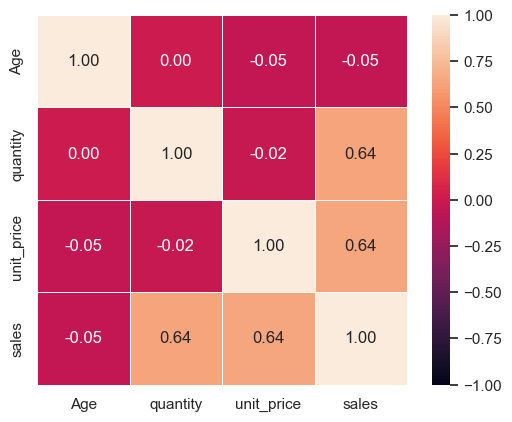

In [187]:
numerical_cols=data[['Age','quantity','unit_price','sales']]
matrix=numerical_cols.corr()
sns.heatmap(matrix,annot=True,fmt=".2f",vmin=-1, vmax=1,linewidths=0.5,square=True)

### Heatmap Correlation Analysis
* **Strong Sales Drivers ($r = 0.64$):** There is a strong, positive, identical correlation ($0.64$) between both `quantity` and `sales`, and `unit_price` and `sales`. This proves that transaction value is equally driven by large order volumes and high-ticket item prices.
* **Zero Demographic Influence ($r = -0.05$):** Age has virtually zero linear relationship with any purchasing metric (`quantity`, `unit_price`, or `sales`). 
* **Key Insight:** Because customer age does not influence the size of their transaction, we should focus on segmenting marketing efforts by *product affinity* and *category interest* rather than age groups.

Text(0.5, 0, 'Total Sales ($)')

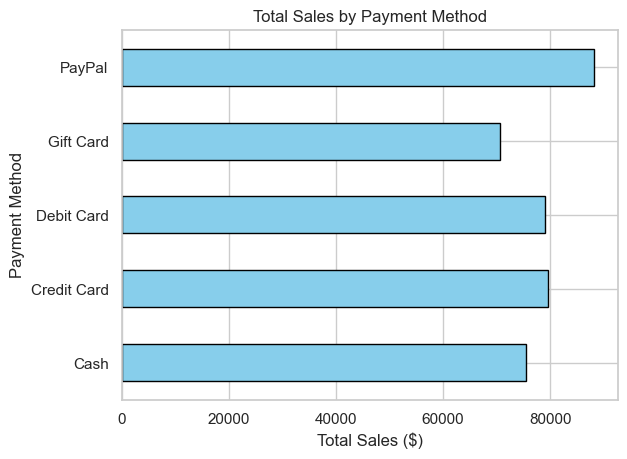

In [204]:
data.groupby('payment_method')['sales'].sum().plot(kind='barh',color='skyblue',edgecolor='black')
plt.title('Total Sales by Payment Method')
plt.ylabel('Payment Method')
plt.xlabel('Total Sales ($)')


### Payment Method Popularity
* **Dominant Method:** **PayPal** is our highest-performing payment gateway, driving nearly \$90,000 in total sales. 
* **Steady Performers:** Credit Cards and Debit Cards are virtually tied, both generating approximately \$80,000 in sales.
* **Lowest Performance:** **Gift Cards** are our least utilized payment method, falling closer to the \$70,000 mark.
* **Key Insight:** Digital and card payment systems make up the overwhelming share of transactions. Optimizing the checkout process for digital wallets like PayPal is essential for minimizing cart abandonment.

## Conclusion

By looking at our sales data, we found exactly when, who, and how people are buying from us. here are **three direct, actionable business recommendations**:

---

### 1. Beat the "September & October" Slump
* **What's happening:** Our sales crash below 10,000 dollar every September and October right before bouncing back up to a huge 22,000 dollar in January. People stop buying right before the holidays.
* **The Fix:** Don't wait for winter! Run special sales, clearance deals, or bundle discounts during September and October to get people shopping early.

### 2. Sell More to Everyone
* **What's happening:** Almost 65% of our shoppers are men, but our best-selling things are **Sports gear, Books (like Textbooks), and Home goods**—which anyone would love.
* **The Fix:** Create ads for these top products that are aimed at girls and other shoppers to easily win over the other 35% of the market we are missing.

### 3. Make PayPal Even Easier
* **What's happening:** Our customers love **PayPal**—it brings in almost \$90,000 in sales, and we make the most money when people buy lots of items at once.
* **The Fix:** Make the PayPal button super easy to find at checkout, and offer a small discount if they buy multiple items using PayPal to get them to buy more.